In [21]:
%load_ext autoreload
%autoreload 2

# Import the library
import greenlearning as gl
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
np.random.seed(42)

dataset_name = "helmholtz"
example_path = "examples/datasets/"
dropout_rate = 0.02
mc_samples = 50

# N_train_arr = np.concat((np.linspace(2, 20, 10, endpoint=True, dtype=int), np.linspace(25, 75, 11, endpoint=True, dtype=int)))
# N_train_arr = np.array([1, 5, 10, 15, 20, 25, 30])
N_train_arr = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75])
noise_ratio = 1e-2
resample = 1
repeats = range(1)
N_test = 20

In [23]:
def relative_L2_error(y_true, y_pred, eps=1e-12):
    """
    Uniform-grid discrete relative L2 error, expressed as a %, averaged over examples on axis=0.
    y_true, y_pred shape: (B, ...grid axes...)
    """
    reduce_axes = tuple(range(1, y_true.ndim))
    num = np.sqrt(np.sum((y_pred - y_true) ** 2, axis=reduce_axes))
    den = np.sqrt(np.sum(y_true ** 2, axis=reduce_axes))
    rel = num / (den + eps)
    return 100 * np.mean(rel)

def empirical_joint_log_likelihood(y_true, y_samples, eps=1e-6):
    """
    Gaussian plug-in log likelihood of the full test set under the empirical
    predictive distribution induced by the Monte Carlo samples.

    y_true shape: (Nx, N_test)
    y_samples shape: (S, Nx, N_test)
    """
    sample_mean = np.mean(y_samples, axis=0)
    sample_std = np.std(y_samples, axis=0)
    sample_std = np.maximum(sample_std, eps)
    log_probs = -0.5 * np.log(2 * np.pi * sample_std ** 2) - 0.5 * ((y_true - sample_mean) / sample_std) ** 2
    return np.sum(log_probs), np.mean(log_probs)

os.makedirs('results_mc_dropout', exist_ok=True)

path = f'{example_path}{dataset_name}.mat'
raw_data = sp.io.loadmat(path)

u = raw_data['F'][::2 * resample, -N_test:]
print('u.shape', u.shape)
v = raw_data['U'][::resample, -N_test:]
print('v.shape', v.shape)

domain_u = raw_data['X'][::resample, 0]
print('domain_u.shape', domain_u.shape)

records = []

for repeat in repeats:
    for N_train in N_train_arr[-1:]:
        G_network = gl.matrix_networks([2] + [50] * 4 + [1], "rational", (1, 1), dropout_rate=dropout_rate)
        U_hom_network = gl.matrix_networks([1] + [50] * 4 + [1], "rational", (1,), dropout_rate=0.0)

        model = gl.Model(
            G_network,
            U_hom_network,
            N_train=N_train,
            noise_ratio=noise_ratio,
            resample=resample,
            repeat=repeat,
            adam_steps=1000, # 1e3
            lbfgs_steps=1000, # 5e4
            dropout_rate=dropout_rate,
            mc_samples=mc_samples,
        )

        model.train(example_path, dataset_name)
        model.save_results()

        X_G, Y_G = np.meshgrid(model.x_G, model.y_G)
        x_G_star = X_G.flatten()[:, None]
        y_G_star = Y_G.flatten()[:, None]
        input_data = np.concatenate((x_G_star, y_G_star), axis=1)

        G_tensor = model.G_network[0][0].evaluate(input_data, keep_prob=model.keep_prob)
        _, _, G_flat_samples = model.mc_predict(G_tensor, mc_samples=mc_samples)
        G_samples = G_flat_samples.reshape((mc_samples,) + X_G.shape)

        sample_path = (
            f'results_mc_dropout/GreenSamples_{dataset_name}_rational_0_'
            f'Ntrain{N_train}_noiseratio{noise_ratio:.6f}_resample{resample}_repeat{repeat}.npy'
        )
        np.save(sample_path, G_samples)

        integrand_samples = G_samples[:, :, :, None] * u[None, None, :, :]
        v_samples = np.trapz(integrand_samples, x=domain_u, axis=2)

        predictive_mean = np.mean(v_samples, axis=0)
        predictive_mean_error = relative_L2_error(v.T, predictive_mean.T)
        empirical_joint_ll, mean_log_likelihood_per_entry = empirical_joint_log_likelihood(v, v_samples)

        for sample_idx in range(mc_samples):
            sample_error = relative_L2_error(v.T, v_samples[sample_idx].T)
            records.append({
                'dataset': dataset_name,
                'N_train': N_train,
                'noise_ratio': noise_ratio,
                'resample': resample,
                'repeat': repeat,
                'dropout_rate': dropout_rate,
                'mc_samples': mc_samples,
                'sample_idx': sample_idx,
                'sample_relative_L2_error': sample_error,
                'predictive_mean_relative_L2_error': predictive_mean_error,
                'empirical_joint_log_likelihood': empirical_joint_ll,
                'mean_log_likelihood_per_entry': mean_log_likelihood_per_entry,
            })

        print(
            f'N_train: {N_train}, repeat: {repeat}, '
            f'predictive mean relative L2 error: {predictive_mean_error:.6f}%, '
            f'empirical joint log likelihood: {empirical_joint_ll:.6f}'
        )

        model.sess.close()

df = pd.DataFrame.from_records(records)
df.to_csv('results/error_vs_N_train_dropout.csv', index=False)
df.head()

u.shape (100, 20)
v.shape (100, 20)
domain_u.shape (100,)
It: 0, Loss = 1.258e+00
It: 10, Loss = 9.944e-01
It: 20, Loss = 9.656e-01
It: 30, Loss = 9.507e-01
It: 40, Loss = 9.404e-01
It: 50, Loss = 9.349e-01
It: 60, Loss = 9.307e-01
It: 70, Loss = 9.324e-01
It: 80, Loss = 9.304e-01
It: 90, Loss = 9.232e-01
It: 100, Loss = 9.225e-01
It: 110, Loss = 9.240e-01
It: 120, Loss = 9.235e-01
It: 130, Loss = 9.239e-01
It: 140, Loss = 9.266e-01
It: 150, Loss = 9.258e-01
It: 160, Loss = 9.251e-01
It: 170, Loss = 9.245e-01
It: 180, Loss = 9.201e-01
It: 190, Loss = 9.230e-01
It: 200, Loss = 9.196e-01
It: 210, Loss = 9.236e-01
It: 220, Loss = 9.221e-01
It: 230, Loss = 9.207e-01
It: 240, Loss = 9.208e-01
It: 250, Loss = 9.170e-01
It: 260, Loss = 9.176e-01
It: 270, Loss = 9.125e-01
It: 280, Loss = 9.088e-01
It: 290, Loss = 9.077e-01
It: 300, Loss = 9.080e-01
It: 310, Loss = 9.056e-01
It: 320, Loss = 9.073e-01
It: 330, Loss = 9.051e-01
It: 340, Loss = 9.049e-01
It: 350, Loss = 9.062e-01
It: 360, Loss = 9

,dataset,N_train,noise_ratio,resample,repeat,dropout_rate,mc_samples,sample_idx,sample_relative_L2_error,predictive_mean_relative_L2_error,empirical_joint_log_likelihood,mean_log_likelihood_per_entry
0,helmholtz,75,0.01,1,0,0.02,50,0,98.150794,24.210117,1365.54669,0.682773
1,helmholtz,75,0.01,1,0,0.02,50,1,96.269463,24.210117,1365.54669,0.682773
2,helmholtz,75,0.01,1,0,0.02,50,2,98.080614,24.210117,1365.54669,0.682773
3,helmholtz,75,0.01,1,0,0.02,50,3,93.576308,24.210117,1365.54669,0.682773
4,helmholtz,75,0.01,1,0,0.02,50,4,96.068964,24.210117,1365.54669,0.682773


test against true green's func

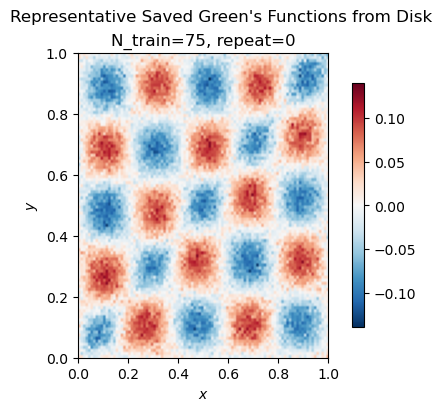

In [24]:
sampled_n_train = 75
sampled_repeats = [0]

fig, axs = plt.subplots(1, len(sampled_repeats), figsize=(4 * len(sampled_repeats), 4), constrained_layout=True)
if len(sampled_repeats) == 1:
    axs = [axs]

for ax, repeat in zip(axs, sampled_repeats):
    green_path = (
        f'results_csv/Green_{dataset_name}_rational_0_'
        f'Ntrain{sampled_n_train}_noiseratio{noise_ratio:.6f}_resample{resample}_repeat{repeat}.csv'
    )
    G_sample = np.genfromtxt(green_path, delimiter=',')

    v = np.max(np.abs(G_sample))

    im = ax.imshow(
        G_sample,
        extent=(domain_u.min(), domain_u.max(), domain_u.min(), domain_u.max()),
        origin='lower',
        aspect='auto',
        cmap='RdBu_r',
        norm=TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
    )
    ax.set_title(f'N_train={sampled_n_train}, repeat={repeat}')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')

fig.colorbar(im, ax=axs, shrink=0.8)
plt.suptitle('Representative Saved Green\'s Functions from Disk')
plt.show()


Loaded sample array shape: (50, 100, 100)
Subset shape: (10, 100, 100)


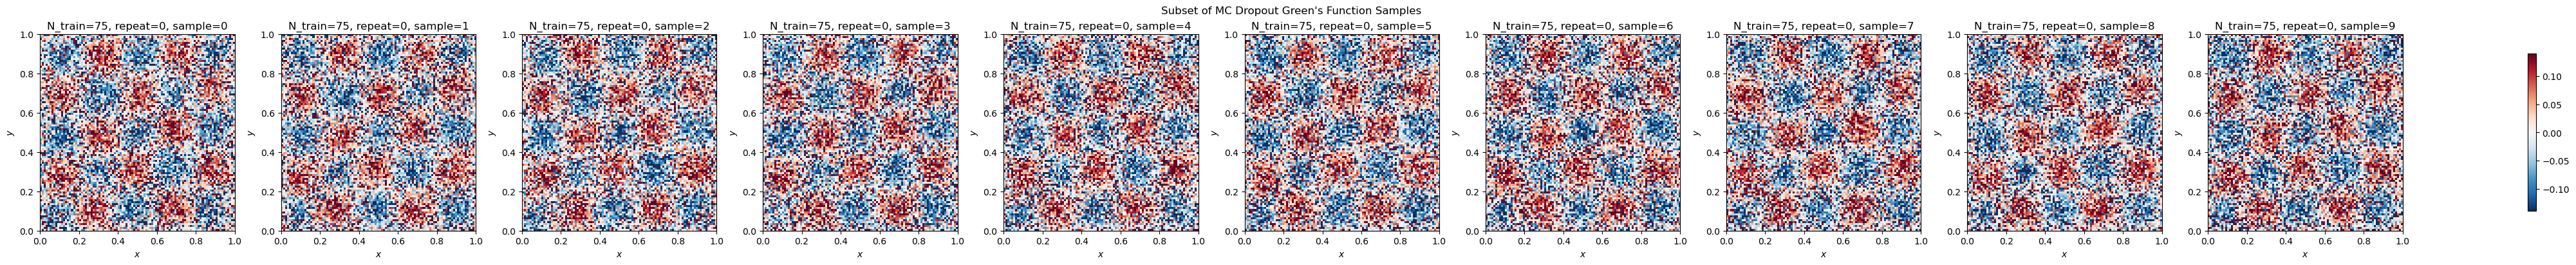

In [25]:
subset_n_train = 75
subset_repeat = 0
subset_sample_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

sample_path = (
    f'results_mc_dropout/GreenSamples_{dataset_name}_rational_0_'
    f'Ntrain{subset_n_train}_noiseratio{noise_ratio:.6f}_resample{resample}_repeat{subset_repeat}.npy'
)

G_samples_subset_source = np.load(sample_path)
G_samples_subset = G_samples_subset_source[subset_sample_indices]
print('Loaded sample array shape:', G_samples_subset_source.shape)
print('Subset shape:', G_samples_subset.shape)

fig, axs = plt.subplots(1, len(subset_sample_indices), figsize=(4 * len(subset_sample_indices), 4), constrained_layout=True)
if len(subset_sample_indices) == 1:
    axs = [axs]

for ax, sample_idx, G_sample in zip(axs, subset_sample_indices, G_samples_subset):
    im = ax.imshow(
        G_sample,
        extent=(domain_u.min(), domain_u.max(), domain_u.min(), domain_u.max()),
        origin='lower',
        aspect='auto',
        cmap='RdBu_r',
        norm=TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
    )
    ax.set_title(f'N_train={subset_n_train}, repeat={subset_repeat}, sample={sample_idx}')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')

fig.colorbar(im, ax=axs, shrink=0.8)
plt.suptitle('Subset of MC Dropout Green\'s Function Samples')
plt.show()


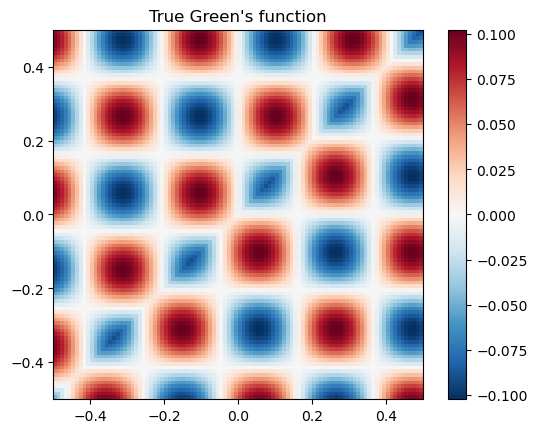

relative L2 error: 145.363698%


: 

In [ ]:
import matplotlib.colors as mcolors

def exact_green(x, y):
    """
    Compute
      f(x,y) = (15*sin(15))**(-1) * ( sin(15*x)*sin(15*(y-1)) if x <= y
                                     else sin(15*y)*sin(15*(x-1)) )

    Supports scalar inputs or numpy arrays (uses broadcasting).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    coef = 1.0 / (15 * np.sin(15))
    term_when_le = np.sin(15 * x) * np.sin(15 * (y - 1))
    term_when_gt = np.sin(15 * y) * np.sin(15 * (x - 1))
    return coef * np.where(x <= y, term_when_le, term_when_gt)

u = raw_data['F'][::2 * resample, -N_test:] # (100, N_test)
domain_u = raw_data['X'][::resample, 0] - 0.5
fine_domain_u = np.linspace(0, 1, 100) - 0.5

X, Y = np.meshgrid(domain_u, fine_domain_u, indexing='ij')  # (100, 100), (100, 100)
G_true = exact_green(X, Y)  # (100, 100)

plt.figure()
plt.imshow(G_true, extent=(domain_u.min(), domain_u.max(), domain_u.min(), domain_u.max()), cmap='RdBu_r', norm=mcolors.TwoSlopeNorm(vcenter=0), origin='lower')
plt.colorbar()
plt.title('True Green\'s function')
plt.show()

integrand = G_true[:, :, None] * u[None, :, :]  # (100, 100, N_test)  # broadcast u over columns (y-axis)

v_est = np.trapz(integrand, x=fine_domain_u, axis=1) # (100, N_test)  # integrate over y (axis=1)

vT = v.T
v_estT = v_est.T

error = relative_L2_error(vT, v_estT)

print(f'relative L2 error: {error:f}%')

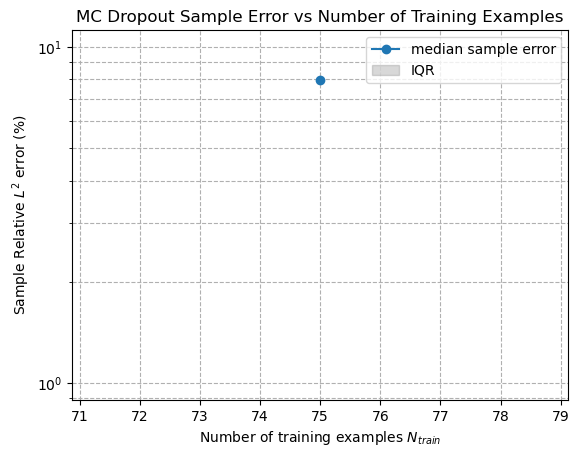

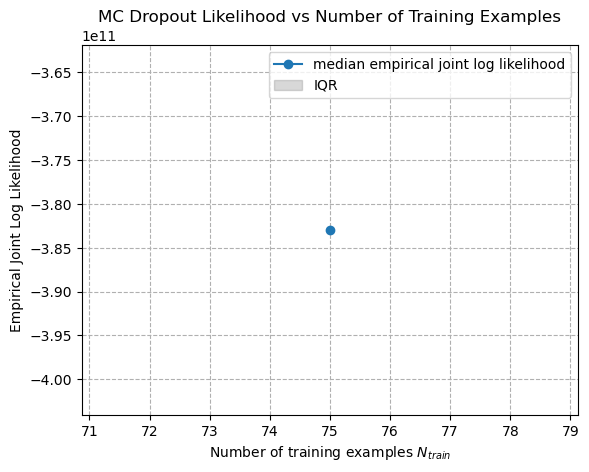

: 

In [ ]:
data = pd.read_csv('results/error_vs_N_train_dropout.csv')

sample_error_grouped = data.groupby('N_train')['sample_relative_L2_error'].agg(
    median='median',
    q25=lambda x: np.percentile(x, 25),
    q75=lambda x: np.percentile(x, 75),
).reset_index()

likelihood_grouped = data.groupby('N_train')['empirical_joint_log_likelihood'].agg(
    median='median',
    q25=lambda x: np.percentile(x, 25),
    q75=lambda x: np.percentile(x, 75),
).reset_index()

plt.figure()
plt.plot(sample_error_grouped['N_train'], sample_error_grouped['median'], 'o-', label='median sample error')
plt.fill_between(sample_error_grouped['N_train'], sample_error_grouped['q25'], sample_error_grouped['q75'], color='gray', alpha=0.3, label='IQR')
plt.yscale('log')
plt.xlabel('Number of training examples $N_{train}$')
plt.ylabel('Sample Relative $L^2$ error (%)')
plt.title('MC Dropout Sample Error vs Number of Training Examples')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()

plt.figure()
plt.plot(likelihood_grouped['N_train'], likelihood_grouped['median'], 'o-', label='median empirical joint log likelihood')
plt.fill_between(likelihood_grouped['N_train'], likelihood_grouped['q25'], likelihood_grouped['q75'], color='gray', alpha=0.3, label='IQR')
plt.xlabel('Number of training examples $N_{train}$')
plt.ylabel('Empirical Joint Log Likelihood')
plt.title('MC Dropout Likelihood vs Number of Training Examples')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()

: 